# Exploração dos dados (EDA)

Primeiro olhar no extrato sintético gerado por `src/data/generate.py`.
O objetivo aqui **não** é modelar nada ainda — é **entender o terreno** e deixar registrado
o que cada observação motiva nos próximos passos (limpeza de texto, escolha de modelo,
detecção de anomalia).

> Os dados são **sintéticos** — nenhum extrato real entra no projeto, por privacidade.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

# O notebook roda a partir de notebooks/; cai pra raiz se necessário.
csv = Path("../data/sample/extrato_exemplo.csv")
if not csv.exists():
    csv = Path("data/sample/extrato_exemplo.csv")

df = pd.read_csv(csv, parse_dates=["data"])
# Colunas auxiliares: módulo do valor e tipo (entrada/saída).
df["valor_abs"] = df["valor"].abs()
df["tipo"] = np.where(df["valor"] >= 0, "crédito", "débito")
print(f"{len(df)} transações | {df['data'].min().date()} a {df['data'].max().date()}")
df.head()

600 transações | 2026-02-01 a 2026-05-31


,data,descricao,valor,categoria,valor_abs,tipo
0,2026-02-01,COMPRA IFOOD *PEDIDO 26499,-27.52,alimentacao,27.52,débito
1,2026-02-01,ENEL SP 303865,-54.73,contas_fixas,54.73,débito
2,2026-02-01,COMPRA AUTO POSTO 9360 355405,-12.65,transporte,12.65,débito
3,2026-02-01,padaria eireli,-17.15,alimentacao,17.15,débito
4,2026-02-01,UBER *EATS,-42.69,alimentacao,42.69,débito


## Visão geral

Tipos das colunas e estatística básica dos valores.

In [2]:
df.info()
df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   data       600 non-null    datetime64[us]
 1   descricao  600 non-null    str           
 2   valor      600 non-null    float64       
 3   categoria  600 non-null    str           
 4   valor_abs  600 non-null    float64       
 5   tipo       600 non-null    str           
dtypes: datetime64[us](1), float64(2), str(3)
memory usage: 46.4 KB


,data,valor,valor_abs
count,600,600.00,600.00
mean,2026-04-01 12:33:36,-82.35,139.06
min,2026-02-01 00:00:00,-5486.10,1.46
25%,2026-03-02 18:00:00,-108.61,29.72
50%,2026-04-01 00:00:00,-51.33,62.46
75%,2026-05-02 00:00:00,-24.00,135.42
max,2026-05-31 00:00:00,1960.46,5486.10
std,NaN,343.64,324.82


## 1. Distribuição por categoria

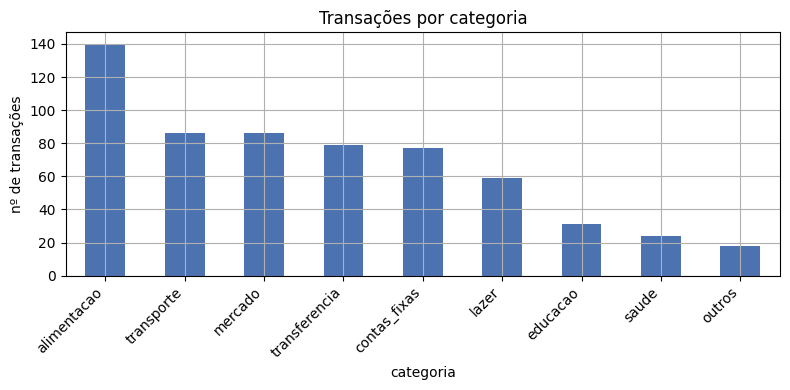

categoria
alimentacao      140
transporte        86
mercado           86
transferencia     79
contas_fixas      77
lazer             59
educacao          31
saude             24
outros            18
Name: count, dtype: int64

Razão maior/menor classe: 7.8x


In [3]:
contagem = df["categoria"].value_counts()
ax = contagem.plot(kind="bar", color="#4C72B0")
ax.set_title("Transações por categoria")
ax.set_xlabel("categoria"); ax.set_ylabel("nº de transações")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

print(contagem)
print(f"\nRazão maior/menor classe: {contagem.max() / contagem.min():.1f}x")

**O que isso motiva:** as classes são bem desbalanceadas (saúde/educação/outros são
raras; alimentação domina). Isso tem duas consequências diretas pra modelagem:

- **Accuracy vai enganar** — um modelo que só chuta a classe majoritária já "acerta" muito.
  Por isso, mais pra frente, vamos olhar **métricas por classe** (precision/recall/f1), não
  só a acurácia global.
- **Recall importa mais nas classes raras de alto custo** (ex.: deixar de identificar um
  gasto de saúde é pior que um falso positivo). Daí usar `class_weight="balanced"` no modelo.

## 2. Distribuição dos valores

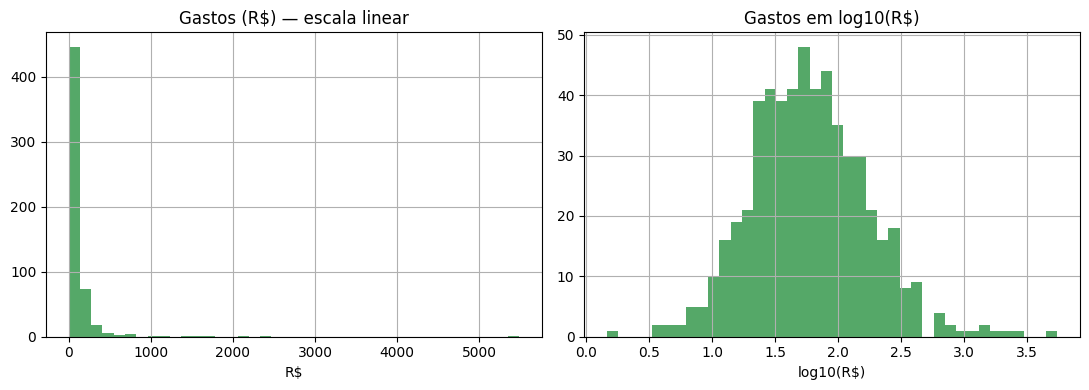

count     557.00
mean      119.25
std       307.76
min         1.46
25%        27.76
50%        55.47
75%       114.48
max      5486.10
Name: valor_abs, dtype: float64


In [4]:
gastos = df[df["tipo"] == "débito"]["valor_abs"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(gastos, bins=40, color="#55A868")
axes[0].set_title("Gastos (R$) — escala linear"); axes[0].set_xlabel("R$")
# Escala log evidencia a cauda longa que a linear esconde.
axes[1].hist(np.log10(gastos), bins=40, color="#55A868")
axes[1].set_title("Gastos em log10(R$)"); axes[1].set_xlabel("log10(R$)")
plt.tight_layout(); plt.show()

print(gastos.describe().round(2))

**O que isso motiva:** distribuição com **cauda longa à direita** — muitos gastos
pequenos, poucos grandes. Confirma a escolha da lognormal no gerador e, mais importante,
**motiva a detecção de anomalia**: "grande" só faz sentido de forma relativa. A escala log
revela a estrutura que a escala linear achata.

## 3. Outliers por categoria

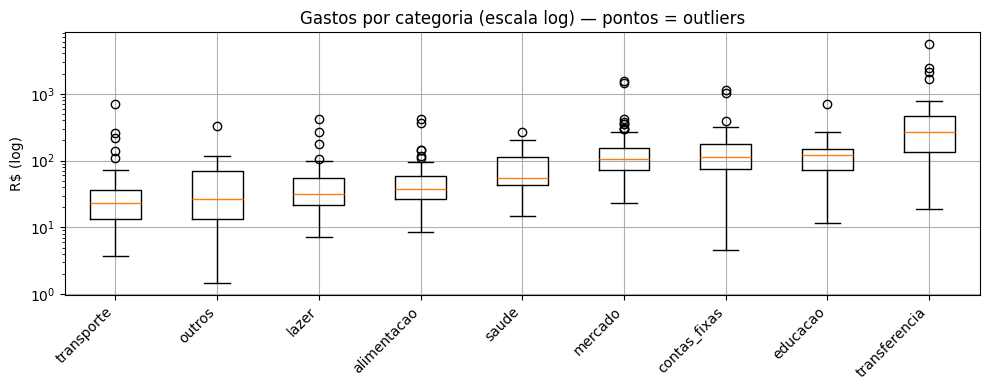

In [5]:
# Boxplot por categoria: pontos fora dos bigodes são candidatos a gasto atípico.
ordem = (df[df.tipo == "débito"]
         .groupby("categoria")["valor_abs"].median().sort_values().index)
dados = [df[(df.categoria == c) & (df.tipo == "débito")]["valor_abs"].values for c in ordem]

plt.figure(figsize=(10, 4))
plt.boxplot(dados, showfliers=True)
plt.yscale("log")  # log pra não achatar as categorias mais baratas
plt.xticks(range(1, len(ordem) + 1), ordem, rotation=45, ha="right")
plt.title("Gastos por categoria (escala log) — pontos = outliers")
plt.ylabel("R$ (log)"); plt.tight_layout(); plt.show()

**O que isso motiva:** cada categoria tem sua **própria escala** (mercado ~R$100,
transporte ~R$20). Um gasto de R$300 é normal no mercado e atípico no transporte. Por isso
a detecção de anomalia vai ser feita **dentro de cada categoria**, não sobre o valor global
— senão todo gasto de mercado pareceria "grande" e todo cafezinho pareceria "normal".

## 4. Padrões de texto

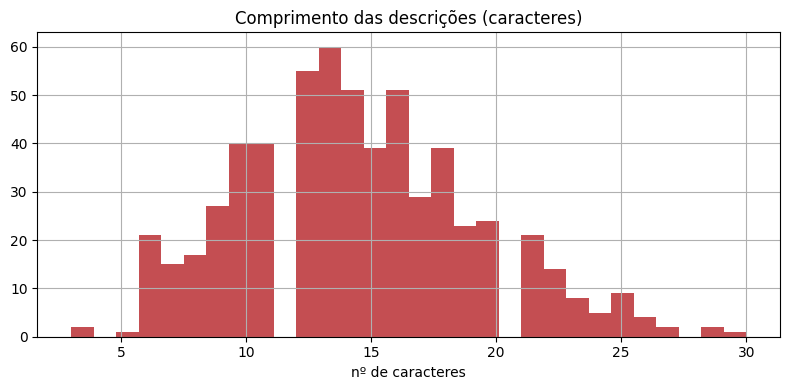

Tokens mais comuns:
  TEF                48
  SP                 31
  COMPRA             24
  POSTO              22
  RECEBIDA           18
  ENVIADA            17
  TED                16
  UBER               15
  PIZZARIA           15
  RECEBIDO           15
  ENEL               14
  BR                 14
  *PEDIDO            12
  ATACAD             12
  DONALDS            12


In [6]:
df["desc_len"] = df["descricao"].str.len()
plt.figure(); plt.hist(df["desc_len"], bins=30, color="#C44E52")
plt.title("Comprimento das descrições (caracteres)"); plt.xlabel("nº de caracteres")
plt.tight_layout(); plt.show()

# Tokens mais frequentes, ignorando tokens puramente numéricos (códigos de loja).
tokens = [t for d in df["descricao"].str.upper() for t in d.split() if not t.isdigit()]
print("Tokens mais comuns:")
for tok, c in Counter(tokens).most_common(15):
    print(f"  {tok:<18} {c}")

In [7]:
# Exemplos do ruído que o feature engineering vai precisar domar:
mask = df["descricao"].str.contains(r"\*|PAG|TEF|COMPRA", case=False, regex=True)
df[mask][["descricao", "categoria"]].sample(10, random_state=3)

,descricao,categoria
589,TEF TED ENVIADA,transferencia
79,pix*joao,outros
326,TEF UBER 516619,transporte
436,uber* viagem,transporte
241,PAGAMENTO RECEBIDO,transferencia
568,tef uber,transporte
593,COMPRA ESTAPAR ESTAC,transporte
579,PAG*IFOOD,alimentacao
318,PAG*IFOOD 715144,alimentacao
54,PAG*PLAYSTATION NET 201119,lazer


**O que isso motiva:** descrições são curtas e barulhentas — prefixos de gateway
(`PAG*`, `TEF`), códigos numéricos de loja e caixa inconsistente. Os tokens mais frequentes
misturam **sinal real** (`IFOOD`, `UBER`, `CARREFOUR`) com **lixo de adquirente** (`PAG`,
`C`, `COMPRA`). Isso aponta para duas decisões de feature engineering:

1. **Normalização** — minúsculas, remover dígitos e prefixos de gateway, colapsar espaços.
2. **TF-IDF com n-grama de caractere** — variações como `IFD` / `IFOOD` compartilham
   subsequências (`ifoo`) mas não tokens inteiros; n-grama de palavra perderia esse sinal.

## Conclusões — o que levamos para os próximos passos

| Observação na EDA | Decisão que motiva |
|---|---|
| Classes desbalanceadas | `class_weight="balanced"` + métricas por classe (recall nas raras) |
| Valores com cauda longa | Detecção de anomalia **por categoria**, não global |
| Texto ruidoso (gateways, códigos, caixa) | Normalização + TF-IDF de **n-grama de caractere** |
| Categorias ambíguas (transferências, `PIX*`) | Esperar confusão entre elas na matriz de confusão |